<a href="https://colab.research.google.com/github/BrionesC/Cardiocotografia/blob/main/Cardiocografia_Actualizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CARDIOTOCOGRAFIA**

---



La cardiotocografía (CTG) es una prueba no invasiva que mide la frecuencia cardíaca del feto, sus movimientos y las contracciones uterinas. La prueba se realiza a través de la piel abdominal con un transductor de ultrasonidos y un transductor de presión.


La CTG se utiliza para detectar peligros para la salud fetal, como la falta de oxígeno o un latido cardíaco inadecuado. También ayuda a los profesionales de la salud a verificar el estado general del feto y a identificar las primeras señales de sufrimiento fetal.


La frecuencia cardíaca fetal promedio se encuentra entre 110 y 160 latidos por minuto. Esta frecuencia puede cambiar como respuesta del feto ante las condiciones intrauterinas.



---



### 1= Normal, 2=Sospechoso, 3= Patológico
countplot cuenta la frecuencia de ocurrencia en la columna NSP

In [ ]:
#Paso 1. montar el drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/MIB/mib

[Errno 2] No such file or directory: '/content/drive/MyDrive/MIB/mib'
/content


In [ ]:
%matplotlib inline
%pylab inline
import numpy as np
#import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="ticks", color_codes=True)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer
from sklearn import metrics
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Populating the interactive namespace from numpy and matplotlib


In [ ]:
#Paso 2. Cargar el dataset
#!pip install --upgrade pandas
!pip install --upgrade xlrd

In [ ]:
# Downgrade pandas a la versión 2.0.3
!pip install pandas==2.0.3

# Reiniciar el entorno después de la instalación
import os
import sys

os.execv(sys.executable, ['python'] + sys.argv)

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# Verificar la versión de pandas
print("Versión de pandas:", pd.__version__)

Versión de pandas: 2.0.3


In [ ]:
xls = pd.ExcelFile('/content/CTG.xls')
#data= pd.read_excel(xls)

sheet_name = 'Raw Data'
data = pd.read_excel(xls, sheet_name=sheet_name)

In [ ]:
data.head()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Variab10.txt,1996-12-01,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,1996-05-03,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,1996-05-03,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,1996-05-03,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0




1. `xls = pd.ExcelFile('CTG.xls')`: Aquí, se crea un objeto `ExcelFile` de pandas llamado `xls`, que representa el archivo Excel llamado 'CTG.xls'. Este objeto `ExcelFile` permite acceder a las hojas de trabajo dentro del archivo Excel y facilita la lectura de datos.

2. `data = pd.read_excel(xls, 'Raw Data')`: En esta línea, se utiliza la función `read_excel` de pandas para leer los datos de la hoja de Excel llamada 'Raw Data'.

In [ ]:
data.tail()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
2125,S8001045.dsp,1998-06-06,CTG2127.txt,1576.0,3049.0,140.0,140.0,1.0,0.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2126,S8001045.dsp,1998-06-06,CTG2128.txt,2796.0,3415.0,142.0,142.0,1.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2127,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2128,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2129,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,564.0,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.shape

(2130, 40)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2130 entries, 0 to 2129
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   FileName  2126 non-null   object        
 1   Date      2126 non-null   datetime64[ns]
 2   SegFile   2126 non-null   object        
 3   b         2126 non-null   float64       
 4   e         2126 non-null   float64       
 5   LBE       2126 non-null   float64       
 6   LB        2126 non-null   float64       
 7   AC        2126 non-null   float64       
 8   FM        2127 non-null   float64       
 9   UC        2127 non-null   float64       
 10  ASTV      2127 non-null   float64       
 11  MSTV      2127 non-null   float64       
 12  ALTV      2127 non-null   float64       
 13  MLTV      2127 non-null   float64       
 14  DL        2128 non-null   float64       
 15  DS        2128 non-null   float64       
 16  DP        2128 non-null   float64       
 17  DR        2128

In [ ]:
# Verificar valores faltantes
print(data.isnull().sum())

# Manejar valores faltantes (si es necesario)
# data.fillna(method='ffill', inplace=True)


FileName    4
Date        4
SegFile     4
b           4
e           4
LBE         4
LB          4
AC          4
FM          3
UC          3
ASTV        3
MSTV        3
ALTV        3
MLTV        3
DL          2
DS          2
DP          2
DR          2
Width       4
Min         4
Max         4
Nmax        4
Nzeros      4
Mode        4
Mean        4
Median      4
Variance    4
Tendency    4
A           4
B           4
C           4
D           4
E           4
AD          4
DE          4
LD          4
FS          4
SUSP        4
CLASS       4
NSP         4
dtype: int64


In [ ]:
#3 eliminar columnas irrelevantes
dataset_rmvCOl = data.drop(columns=['FileName','SegFile', 'Date'])
dataset_rmvCOl.head()

,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,240.0,357.0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,5.0,632.0,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,177.0,779.0,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0


dataset_rmvCol = data.drop(columns=['FileName','SegFile', 'Date']): En esta línea, se crea un nuevo DataFrame llamado dataset_rmvCol al eliminar las columnas especificadas ('FileName', 'SegFile', 'Date') del DataFrame original llamado data. La función drop se utiliza para eliminar columnas en pandas, y el argumento columns se utiliza para especificar los nombres de las columnas que se deben eliminar.

dataset_rmvCol.head(): En esta línea, se imprime en la consola las primeras filas del nuevo DataFrame resultante. La función head() de pandas se utiliza para mostrar las primeras filas de un DataFrame y proporciona una vista previa de los datos después de realizar la eliminación de columnas.









In [ ]:
#4 eliminar  valores nulos NaN
finaldata = dataset_rmvCOl.dropna()
finaldata.head()

,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
1,240.0,357.0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,5.0,632.0,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,177.0,779.0,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
5,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,16.0,2.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [ ]:
finaldata.shape

(2126, 37)

NSP
1.0    [[Axes(0.125,0.7925;0.103333x0.0875), Axes(0.2...
2.0    [[Axes(0.125,0.7925;0.103333x0.0875), Axes(0.2...
3.0    [[Axes(0.125,0.7925;0.103333x0.0875), Axes(0.2...
dtype: object

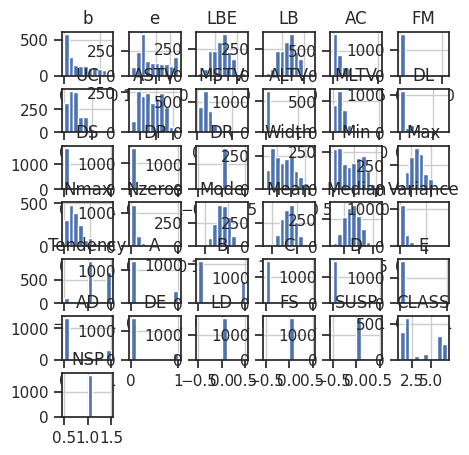

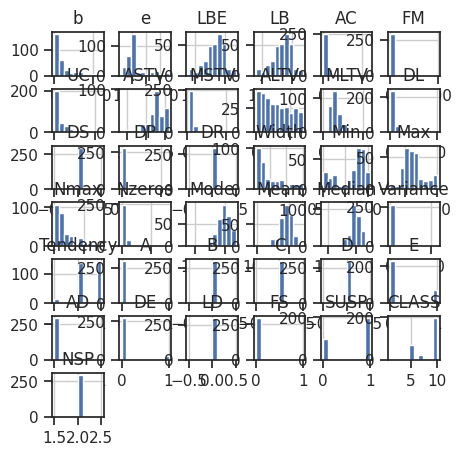

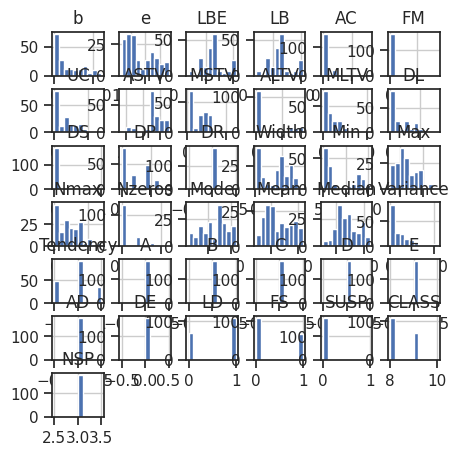

In [ ]:
finaldata.groupby('NSP').hist(figsize=(5, 5))


finaldata.groupby('NSP'): Se agrupan los datos en el DataFrame finaldata por la columna 'NSP'. Esto significa que los datos se dividirán en grupos según los valores únicos en la columna 'NSP'.

hist(figsize=(12, 12)): Se aplica el método hist() para generar histogramas de las columnas numéricas dentro de cada grupo. La opción figsize=(12, 12) establece el tamaño de la figura de los histogramas en 12 por 12 pulgadas.

Ten en cuenta que esta línea de código asume que finaldata es un DataFrame de pandas y que 'NSP' es una columna dentro de este DataFrame. Además, este código se espera que se ejecute en un entorno que tenga las bibliotecas adecuadas importadas, como pandas y matplotlib.

In [ ]:
# Paso 5. Explorar los datos y visualizarlos

### 1= Normal, 2=Sospechoso, 3= Patológico
countplot cuenta la frecuencia de ocurrencia en la columna NSP

sns.countplot(x='NSP', data=finaldata, palette='hls'): Se utiliza Seaborn para crear un gráfico de barras (countplot) donde en el eje x se representa la columna 'NSP' del DataFrame finaldata. La paleta de colores 'hls' se utiliza para definir los colores de las barras.

ax.set_title('NSP', fontsize=20): Se establece el título del gráfico como 'NSP' con un tamaño de fuente de 20.

El bucle for p in ax.patches itera sobre cada barra en el gráfico. La función ax.annotate se utiliza para agregar etiquetas a las barras que representan la altura (frecuencia) de cada categoría.

plt.show(): Finalmente, se muestra el gráfico.

###NORMALIZAR

Normalizar los datos
Recordar quE NO SE DEBE NORMALIZAR EL LABEL que generalmente está en la última columna.
esto aplicia a todas las tareas. !!





CAMMBIO X E Y

In [ ]:
# Paso 6. Dividir los datos en: Entrada X - variables/features/atributos; y, salida y - labels/etiquetas

In [ ]:
finaldata.shape

(2126, 37)

In [ ]:
# otra forma de hacerlo.
# Obtener las columnas desde la primera hasta la columna 35
xx = finaldata.columns[0:36]

# Seleccionar las columnas correspondientes en el DataFrame finaldata
x = finaldata[xx]

# Mostrar el DataFrame x
print(x)


,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,...,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS
1,240.0,357.0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0
2,5.0,632.0,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0
3,177.0,779.0,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0
4,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0
5,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,16.0,2.4,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2122,2059.0,2867.0,140.0,140.0,0.0,0.0,6.0,79.0,0.2,25.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0
2123,1576.0,2867.0,140.0,140.0,1.0,0.0,9.0,78.0,0.4,22.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0
2124,1576.0,2596.0,140.0,140.0,1.0,0.0,7.0,79.0,0.4,20.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0
2125,1576.0,3049.0,140.0,140.0,1.0,0.0,9.0,78.0,0.4,27.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0


finaldata.columns[0:36]: Utiliza la propiedad columns de un DataFrame para obtener el nombre de todas las columnas y luego selecciona las columnas desde la primera hasta la columna 35. Esto crea una lista de nombres de columnas llamada xx.

finaldata[xx]: Selecciona las columnas correspondientes en el DataFrame finaldata utilizando la lista de nombres de columnas xx. Esto crea un nuevo DataFrame llamado x que contiene solo las columnas seleccionadas.

In [ ]:
# Obtener la columna en el índice 36 (columna 37 considerando índices base 0)
features1 = list(finaldata.columns[36:37])

# Seleccionar la columna correspondiente en el DataFrame finaldata
y = finaldata[features1]

# Mostrar el DataFrame y
print(y)


,NSP
1,2.0
2,1.0
3,1.0
4,1.0
5,1.0
...,...
2122,2.0
2123,2.0
2124,2.0
2125,2.0


En resumen, el código extrae una única columna específica del DataFrame finaldata y la almacena en un nuevo DataFrame llamado y.

In [ ]:
#Mostrar y
y

,NSP
1,2.0
2,1.0
3,1.0
4,1.0
5,1.0
...,...
2122,2.0
2123,2.0
2124,2.0
2125,2.0


In [ ]:
finaldata.shape

(2126, 37)

In [ ]:
# Paso 7. Dividimos el 75% de los datos para entrenamiento y el 25% para prueba
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
# X_train: Conjunto de características de entrenamiento
# X_test: Conjunto de características de prueba
# y_train: Etiquetas de entrenamiento
# y_test: Etiquetas de prueba
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=30)

# Mostrar el conjunto de características de entrenamiento (X_train)
print(X_train)


,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,...,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS
2017,2093.0,3016.0,125.0,125.0,0.0,0.0,9.0,65.0,1.2,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,7.0
62,537.0,1192.0,146.0,146.0,3.0,0.0,3.0,39.0,0.8,21.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
279,17.0,740.0,123.0,123.0,0.0,0.0,2.0,50.0,0.5,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
562,0.0,1199.0,128.0,128.0,1.0,0.0,12.0,37.0,2.8,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0
862,1695.0,2365.0,142.0,142.0,2.0,0.0,3.0,46.0,0.7,27.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
920,1677.0,2360.0,122.0,122.0,0.0,0.0,3.0,39.0,0.8,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1165,910.0,1379.0,131.0,131.0,5.0,0.0,7.0,26.0,1.5,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
501,0.0,1199.0,131.0,131.0,17.0,18.0,1.0,29.0,3.7,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
422,0.0,1199.0,143.0,143.0,0.0,0.0,4.0,65.0,0.6,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0


me sirve para calcular la exactitud del modelo

In [ ]:
#Mostrar la etiqueta y_train
y_train

,NSP
2017,1.0
62,1.0
279,1.0
562,1.0
862,1.0
...,...
920,1.0
1165,1.0
501,1.0
422,2.0


In [ ]:

# normalizo los datos con las mismas variables para comparar el efecto de la normalización en el aprendizaje.
from sklearn.preprocessing import StandardScaler

# Crear un objeto StandardScaler para normalizar los datos de entrenamiento
scaler1 = StandardScaler()

# Ajustar el scaler y transformar X_train
scaler1.fit(X_train)
X_train = scaler1.transform(X_train)

# Crear un objeto StandardScaler separado para normalizar los datos de prueba
scaler2 = StandardScaler()

# Ajustar el scaler y transformar X_test
scaler2.fit(X_test)
X_test = scaler1.transform(X_test)

# Mostrar el conjunto de características de prueba normalizado (X_test)
print(X_test)


array([[ 0.23006641,  0.47523568,  1.48546131, ..., -0.20272121,
        -0.28896895, -0.8465176 ],
       [-0.96031126, -1.03896854, -1.82781003, ..., -0.20272121,
        -0.28896895, -0.8465176 ],
       [-0.71077033, -0.86376258, -1.02459274, ...,  4.93288286,
        -0.28896895,  1.52195087],
       ...,
       [-0.49832333, -0.52821662,  0.07983104, ..., -0.20272121,
        -0.28896895,  0.50689296],
       [ 1.81611258,  1.81635765,  0.1802332 , ..., -0.20272121,
        -0.28896895, -0.8465176 ],
       [-0.95693909, -1.05808191,  0.28063537, ..., -0.20272121,
        -0.28896895,  0.8452456 ]])

StandardScaler(): Crea un objeto StandardScaler, que se utilizará para estandarizar (normalizar) los datos.

scaler1.fit(X_train): Ajusta el scaler utilizando los datos de entrenamiento (X_train). Esto calcula la media y la desviación estándar de cada característica en X_train.

X_train = scaler1.transform(X_train): Transforma (normaliza) los datos de entrenamiento utilizando el scaler ajustado. Esto resta la media y divide por la desviación estándar, estandarizando así los datos.

Se repiten los pasos 2-3 para los datos de prueba (X_test), utilizando un objeto StandardScaler separado (scaler2).


Se utilizó MinMaxScaler en lugar de StandardScaler para realizar la escala min-max.

In [ ]:
# Paso 8. Creamos una instancia del modelo de regresión logística y la función fit() para entrenar el modelo

En scikit-learn, el parámetro solver se utiliza para especificar el algoritmo de optimización a utilizar. Algunos de los solvers comunes incluyen 'lbfgs', 'liblinear', 'newton-cg', entre otros. Sin embargo, 'warn' no es un solver en sí mismo, sino una opción que se puede utilizar para manejar advertencias relacionadas con el solver.

Si quieres especificar un solver específico, deberías usar su nombre como cadena en lugar de 'warn'. Por ejemplo:

model = LogisticRegression(solver='lbfgs')


In [ ]:
from sklearn.linear_model import LogisticRegression

# Crear un objeto de regresión logística con 'multi_class' configurado en 'auto'
logreg = LogisticRegression(multi_class='auto')

# Ajustar el modelo de regresión logística con los datos de entrenamiento
logreg.fit(X_train, y_train)


LogisticRegression()

from sklearn.linear_model import LogisticRegression: Importa la clase LogisticRegression de scikit-learn, que se utiliza para realizar regresión logística.

logreg = LogisticRegression(multi_class='auto'): Crea un objeto de regresión logística con el parámetro multi_class configurado en 'auto'. La configuración 'auto' permite que el modelo seleccione automáticamente entre 'ovr' (uno contra todos) y 'multinomial' (entropía cruzada multinomial) según la naturaleza del problema.

logreg.fit(X_train, y_train): Ajusta el modelo de regresión logística utilizando los datos de entrenamiento X_train (conjunto de características) y y_train (etiquetas). Esto significa que el modelo está aprendiendo los parámetros óptimos para realizar la clasificación.

In [ ]:
# Paso 9. Con el modelo entrenado, hacer predicciones con la base de prueba
# Hacer predicciones en el conjunto de prueba
y_pred = logreg.predict(X_test)

# Mostrar las primeras filas de las etiquetas reales en el conjunto de prueba
y_test.head()


,NSP
1455,1.0
1274,1.0
652,3.0
96,1.0
471,3.0


y_pred = logreg.predict(X_test): Utiliza el modelo de regresión logística entrenado (logreg) para predecir las etiquetas en el conjunto de prueba (X_test). Las predicciones se almacenan en la variable y_pred.

y_test.head(): Muestra las primeras filas de las etiquetas reales en el conjunto de prueba (y_test). Esto proporciona una comparación visual entre las etiquetas reales y las predicciones hechas por el modelo.

Después de ejecutar este bloque de código, y_pred contendrá las predicciones del modelo para el conjunto de prueba, y y_test.head() mostrará las primeras filas de las etiquetas reales en el conjunto de prueba. Esto puede ser útil para evaluar el rendimiento del modelo comparando las predicciones con las etiquetas reales.

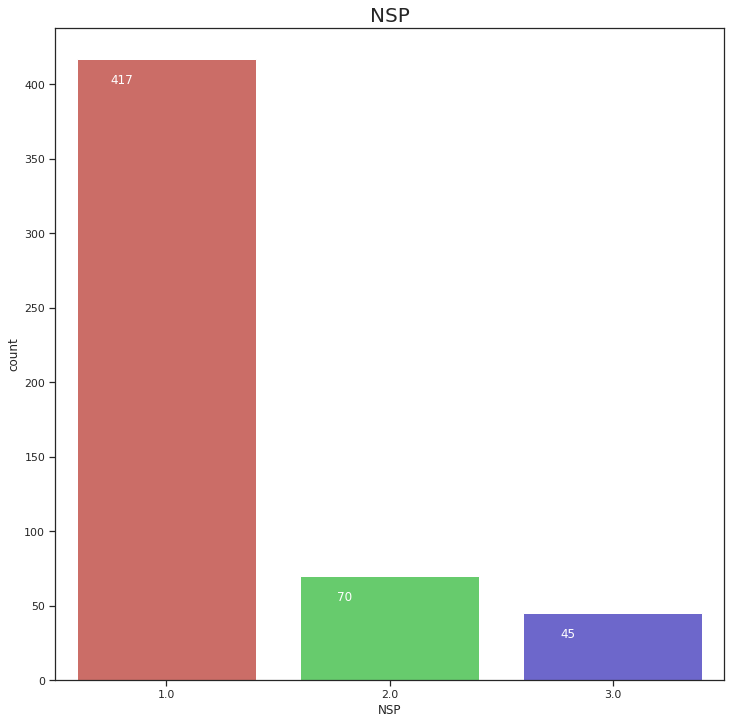

In [ ]:
# Crear un DataFrame a partir de las etiquetas reales del conjunto de prueba (y_test)
df = pd.DataFrame(y_test)

# Crear un gráfico de barras utilizando Seaborn
ax = sns.countplot(x='NSP', data=df, palette='hls')

# Establecer el título del gráfico
ax.set_title('NSP', fontsize=20)

# Etiquetar cada barra con su altura (frecuencia)
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}', (p.get_x() + 0.2, p.get_height()), ha='center', va='top', color='white', size=12)

# Mostrar el gráfico
plt.show()


In [ ]:
df.groupby('NSP').size()
#Al ejecutar este código, obtendrás un resultado que indica cuántas instancias
#hay para cada valor único en la columna 'NSP'.
#Esto es útil para entender la distribución de las clases en tus datos
# reales del conjunto de prueba.

NSP
1.0    417
2.0     70
3.0     45
dtype: int64

In [ ]:
# Evaluamos el modelo con la matriz de confusion
# Calcular la matriz de confusión
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
cnf_matrix


array([[417,   0,   0],
       [  4,  66,   0],
       [  0,   0,  45]])

Al ejecutar este código, obtendrás una matriz cuadrada que muestra la cantidad de verdaderos positivos (TP), verdaderos negativos (TN), falsos positivos (FP) y falsos negativos (FN) para cada clase en tus datos de prueba. Esta información es fundamental para evaluar la precisión y el rendimiento del modelo en tareas de clasificación.

Matriz de Confusión: 

[[417   0   0]
 [  4  66   0]
 [  0   0  45]]


Text(0.5, 1.0, 'Matriz de Confusión ')

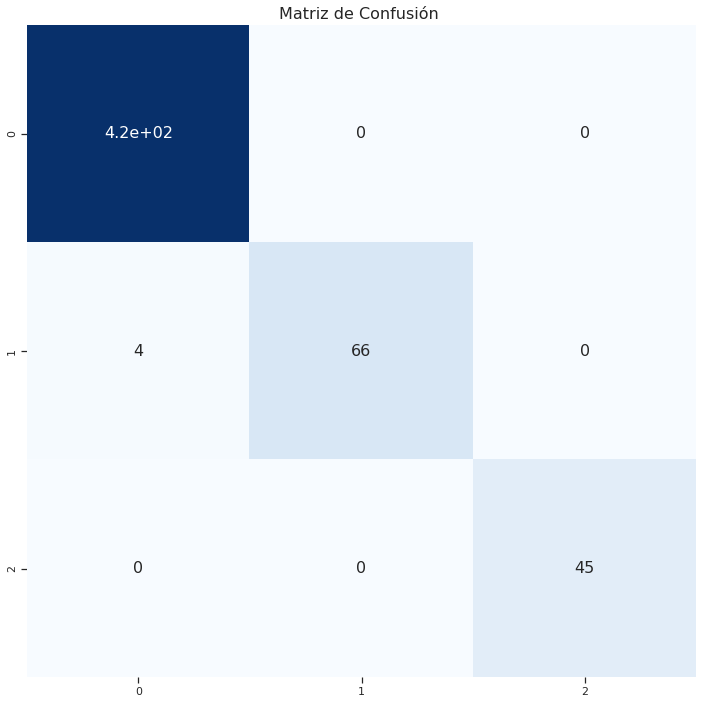

In [ ]:
# Time for Prediction and Plotting Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Hacer predicciones en el conjunto de prueba
Y_pred = logreg.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, Y_pred)
print("Matriz de Confusión: \n")
print(cm)

# Crear un DataFrame a partir de la matriz de confusión
df_cm = pd.DataFrame(cm, range(3), range(3))

# Crear un mapa de calor de la matriz de confusión
sns.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cbar=False, cmap=plt.cm.Blues)

# Establecer el título del gráfico
plt.title("Matriz de Confusión", fontsize=16)


Este bloque de código mostrará un mapa de calor de la matriz de confusión, lo que facilita la visualización de los resultados del modelo en términos de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos para cada clase.

In [ ]:
# La matriz de confusión tiene dimensión 3x3, porque es un clasificador multiclase 1, 2 y 3
# Los valores diagonales representan predicciones precisas
# Los valores no diagonales son predicciones inexactas
# Los valores 407, 63 y 50 son predicciones reales, mientras que el resto son predicciones incorrectas

In [ ]:
# Visualicemos los resultados del modelo en forma de una matriz de confusión usando matplotlib y seaborn

Este código generará un mapa de calor de la matriz de confusión, con las etiquetas de las clases en los ejes x e y, y con las celdas de la matriz etiquetadas con los valores correspondientes. Este tipo de visualización es útil para evaluar cómo el modelo está clasificando las diferentes clases.

Cómo interpretar la matriz
Las columnas son las predicciones y las filas son los valores reales

La diagonal principal (417, 66, 45) son las predicciones correctas. Es decir, los casos en que los valores reales y las predicciones del modelo son los mismos

1 = normal; 2 = sospechoso; 3 = patológico

La primera fila son los normales. El modelo predijo 407 de estos correctamente, e incorrectamente predijo que de los normales, 2 eran sospechosos y 1 era patológico

En la columna 1, de los 416 normales predichos por el modelo (suma de la columna 1), 407 eran en realidad normales, mientras que 9 eran sospechosos que se predijeron incorrectamente como normales y no hubo patologicos que se predijeran incorrectamente como normales; y así el resto de filas, columnas

In [ ]:
# Precisión del modelo

In [ ]:
print("Exactitud:",metrics.accuracy_score(y_test, y_pred))

Exactitud: 0.9924812030075187


La exactitud es una métrica común para evaluar el rendimiento de un modelo de clasificación. Indica la proporción de predicciones correctas en relación con el total de predicciones. Un valor de exactitud cercano a 1.0 significa que el modelo está haciendo predicciones precisas en la mayoría de los casos.

In [ ]:
# Veamos el area bajo la curva

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_auc_score

def multiclass_roc_auc_score(y_test, y_pred, average="macro"):
    # Binzariza las etiquetas reales y predichas
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test = lb.transform(y_test)
    y_pred = lb.transform(y_pred)

    # Calcula el Área bajo la Curva ROC para el problema multiclase
    return roc_auc_score(y_test, y_pred, average=average)

# Llama a la función y obtiene el AUC
auc = multiclass_roc_auc_score(y_test, y_pred, average="macro")

# Imprime el resultado
print("Área bajo la curva:", auc)


Area bajo la curva:  0.9846790890269151


El Área bajo la Curva ROC (AUC) es una métrica útil para evaluar la calidad de un modelo de clasificación, especialmente en problemas multiclase. Un valor de AUC cercano a 1.0 indica un buen rendimiento del modelo.

# PRÁCTICA
Contiene tareas con código base que pueden cambiar a su gusto y probar con el archivo subido en clase.

Tarea 1: realizar la clasificación usando regresión logística normalizando los datos de entrada

Tarea 2: realizar la clasificación usando SVM o knn o rf con los datos normalizados.
Si deseas realizar la clasificación utilizando SVM, k-Nearest Neighbors (k-NN) o Random Forest (RF) con los datos normalizados, puedes seguir un proceso similar al proporcionado anteriormente para la regresión logística.

Tarea 3: realizar la clasificación usando PCA y luego aplican SVM y regresión logística.

Para realizar la clasificación utilizando PCA y luego aplicar Support Vector Machine (SVM) y regresión logística, primero debes realizar la reducción de dimensionalidad con PCA y luego entrenar los modelos SVM y regresión logística en los nuevos conjuntos de datos reducidos.